# Harjoitustehtävä


### Koneoppimisversio Random Forrestilla

                                                text  label
0  I have bought several of the Vitality canned d...      1
1  Product arrived labeled as Jumbo Salted Peanut...      1
2  This is a confection that has been around a fe...      1
3  If you are looking for the secret ingredient i...      1
4  Great taffy at a great price.  There was a wid...      1
(22295, 2)


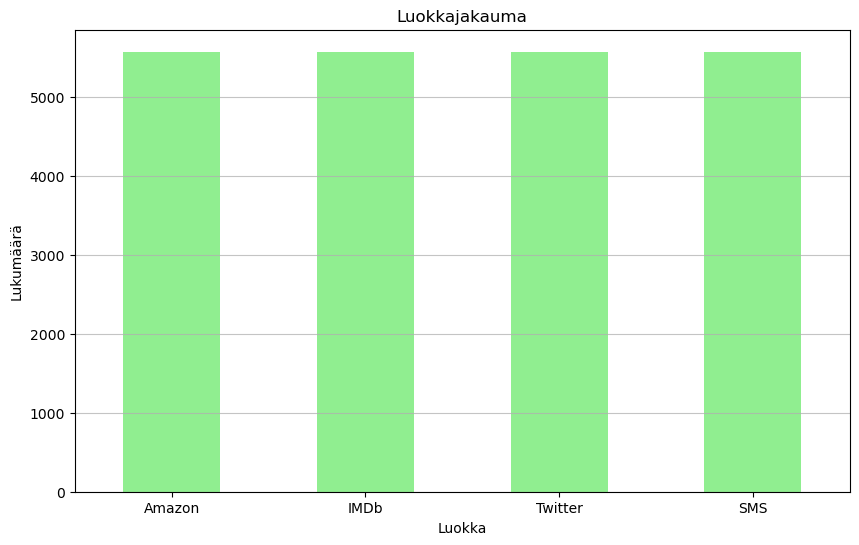

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tuodaan data
amazon_reviews_df = pd.read_csv('data/amazon-reviews.csv', usecols=['Text'])
imdb_reviews_df = pd.read_csv('data/imdb-reviews.csv', usecols=['review'])
tweets_df = pd.read_csv('data/tweets.csv', usecols=['text'])
sms_df = pd.read_csv('data/sms-messages.csv', usecols=['SMS'])

# Nimetään sarakkeet samaksi
amazon_reviews_df = amazon_reviews_df.rename(columns={'Text': 'text'})
imdb_reviews_df = imdb_reviews_df.rename(columns={'review': 'text'})
tweets_df = tweets_df.rename(columns={'text': 'text'})  
sms_df = sms_df.rename(columns={'SMS': 'text'})

# Lisätään label-sarake jokaiseen DataFrameen
amazon_reviews_df['label'] = 1  # Amazon-arvostelut = label 1
imdb_reviews_df['label'] = 2    # IMDb-arvostelut = label 2
tweets_df['label'] = 3          # Twitter-viestit = label 3
sms_df['label'] = 4             # SMS-viestit = label 4

# Leikataan data pienimmän datasetin mukaan
min_length = min(len(amazon_reviews_df), len(imdb_reviews_df), len(tweets_df), len(sms_df))

amazon_reviews_df = amazon_reviews_df.iloc[:min_length]
imdb_reviews_df = imdb_reviews_df.iloc[:min_length]
tweets_df = tweets_df.iloc[:min_length]
sms_df = sms_df.iloc[:min_length]

# Yhdistetään DataFramet
combined_df = pd.concat([amazon_reviews_df, imdb_reviews_df, tweets_df, sms_df], ignore_index=True)

# Poistetaan puuttuvat rivit pysyvästi
combined_df = combined_df.dropna()

# Tarkistetaan yhdistetty DataFrame
print(combined_df.head())
print(combined_df.shape)

# Luokkajakauma
# Lasketaan luokkajakauma
label_counts = combined_df['label'].value_counts()

# Visualisoidaan luokkajakauma
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color='lightgreen')
plt.title('Luokkajakauma')
plt.xlabel('Luokka')
plt.ylabel('Lukumäärä')
plt.xticks(ticks=range(len(label_counts)), labels=['Amazon', 'IMDb', 'Twitter', 'SMS'], rotation=0)
plt.grid(axis='y', alpha=0.75)
plt.show()


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Tekstin muuntaminen numeeriseen muotoon TF-IDF-muuntajalla
tfidf = TfidfVectorizer()

# Muunnamme tekstidatan numeeriseksi
X = tfidf.fit_transform(combined_df['text'])  
y = combined_df['label']  

# Jaetaan data koulutus- ja testijoukkoihin
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Luo Random Forest -luokittelija
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Koulutetaan luokittelija
rf_classifier.fit(X_train, y_train)

# Ennustetaan testijoukolla
y_pred = rf_classifier.predict(X_test)

# Lasketaan tarkkuus
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.8676833370710921


# NPL-syväoppimismallit

### LSTM-malli

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.preprocessing.text import Tokenizer
from keras_preprocessing.sequence import pad_sequences
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization
from sklearn.metrics import accuracy_score
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.regularizers import l2

# Tuodaan data
amazon_reviews_df = pd.read_csv('data/amazon-reviews.csv', usecols=['Text'])
imdb_reviews_df = pd.read_csv('data/imdb-reviews.csv', usecols=['review'])
tweets_df = pd.read_csv('data/tweets.csv', usecols=['text'])
sms_df = pd.read_csv('data/sms-messages.csv', usecols=['SMS'])

# Nimetään sarakkeet samaksi esimerkiksi 'text'
amazon_reviews_df = amazon_reviews_df.rename(columns={'Text': 'text'})
imdb_reviews_df = imdb_reviews_df.rename(columns={'review': 'text'})
tweets_df = tweets_df.rename(columns={'text': 'text'})  
sms_df = sms_df.rename(columns={'SMS': 'text'})


# Lisätään label-sarake jokaiseen DataFrameen
amazon_reviews_df['label'] = 1  # Amazon-arvostelut = label 1
imdb_reviews_df['label'] = 2    # IMDb-arvostelut = label 2
tweets_df['label'] = 3          # Twitter-viestit = label 3
sms_df['label'] = 4             # SMS-viestit = label 4

# Leikataan data pienimmän datasetin mukaan
min_length = min(len(amazon_reviews_df), len(imdb_reviews_df), len(tweets_df), len(sms_df))

amazon_reviews_df = amazon_reviews_df.iloc[:min_length]
imdb_reviews_df = imdb_reviews_df.iloc[:min_length]
tweets_df = tweets_df.iloc[:min_length]
sms_df = sms_df.iloc[:min_length]

# Yhdistetään DataFramet
combined_df = pd.concat([amazon_reviews_df, imdb_reviews_df, tweets_df, sms_df], ignore_index=True)

# Poistetaan puuttuvat rivit pysyvästi
combined_df = combined_df.dropna()

# Tekstin esikäsittely
max_words = 10000  # Sanaston koko
max_length = 100  # Tekstien maksimi pituus

# Tokenisoidaan tekstit
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(combined_df['text'])
sequences = tokenizer.texts_to_sequences(combined_df['text'])

# Pad-sekvenssit
X = pad_sequences(sequences, maxlen=max_length)

# Muutetaan etiketit niin, että ne alkavat nollasta
y = combined_df['label'].values - 1  # Vähennetään 1 jokaisesta etiketistä

# Jaetaan data koulutus- ja testijoukkoihin
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mallin luominen
model = Sequential()
model.add(Embedding(max_words, 128, input_length=max_length))  
model.add(LSTM(128, return_sequences=True))
model.add(BatchNormalization())
model.add(Dropout(0.5))  
model.add(LSTM(64))
model.add(Dropout(0.5))  
model.add(Dense(64, activation='relu', kernel_regularizer=l2(0.01)))  
model.add(Dropout(0.5))  
model.add(Dense(4, activation='softmax', kernel_regularizer=l2(0.01)))  

# Mallin kääntäminen
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Varhainen lopetus ylikoulutuksen estämiseksi
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=0.001)

# Mallin koulutus
history = model.fit(X_train, y_train, 
                    epochs=6, 
                    batch_size=32, 
                    validation_split=0.2, 
                    callbacks=[early_stopping, reduce_lr])

# Ennustetaan testijoukolla
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Lasketaan tarkkuus
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Accuracy: {accuracy}")


Epoch 1/6
446/446 [==============================] - 56s 113ms/step - loss: 0.9116 - accuracy: 0.7652 - val_loss: 0.4966 - val_accuracy: 0.8442 - lr: 0.0010
Epoch 2/6
446/446 [==============================] - 49s 110ms/step - loss: 0.3596 - accuracy: 0.9231 - val_loss: 0.3368 - val_accuracy: 0.9095 - lr: 0.0010
Epoch 3/6
446/446 [==============================] - 52s 118ms/step - loss: 0.2668 - accuracy: 0.9460 - val_loss: 0.3163 - val_accuracy: 0.9013 - lr: 0.0010
Epoch 4/6
446/446 [==============================] - 50s 113ms/step - loss: 0.2316 - accuracy: 0.9545 - val_loss: 0.3141 - val_accuracy: 0.9103 - lr: 0.0010
Epoch 5/6
446/446 [==============================] - 49s 109ms/step - loss: 0.1927 - accuracy: 0.9658 - val_loss: 0.3140 - val_accuracy: 0.9123 - lr: 0.0010
Epoch 6/6
140/140 [==============================] - 6s 30ms/step
Accuracy: 0.9145548329221799


# Mallin suorituskyvyn visualisointi

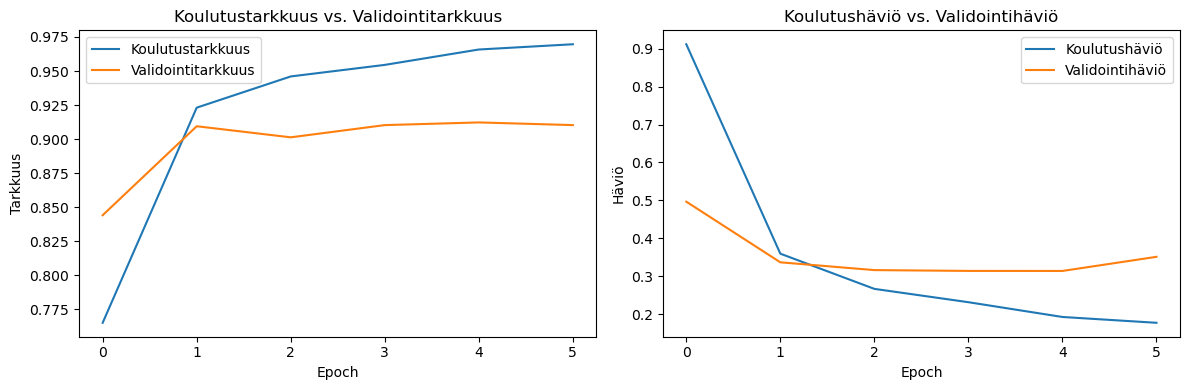

In [17]:
import matplotlib.pyplot as plt

# Visualisoi tarkkuus ja häviö
plt.figure(figsize=(12, 4))

# Koulutustarkkuuden visualisointi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Koulutustarkkuus')
plt.plot(history.history['val_accuracy'], label='Validointitarkkuus')
plt.title('Koulutustarkkuus vs. Validointitarkkuus')
plt.xlabel('Epoch')
plt.ylabel('Tarkkuus')
plt.legend()

# Häviön visualisointi
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Koulutushäviö')
plt.plot(history.history['val_loss'], label='Validointihäviö')
plt.title('Koulutushäviö vs. Validointihäviö')
plt.xlabel('Epoch')
plt.ylabel('Häviö')
plt.legend()

plt.tight_layout()
plt.show()


### Häviö ja tarkkuus

### Luokitteluraportti

In [18]:
from sklearn.metrics import classification_report

# Laske ennustukset testijoukolle
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Tulosta luokitteluraportti
print(classification_report(y_test, y_pred_classes))


140/140 [==============================] - 4s 30ms/step
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1129
           1       0.99      1.00      0.99      1138
           2       0.82      0.88      0.85      1103
           3       0.86      0.80      0.83      1089

    accuracy                           0.91      4459
   macro avg       0.91      0.91      0.91      4459
weighted avg       0.92      0.91      0.91      4459



### Sekalaisuusmatriisi

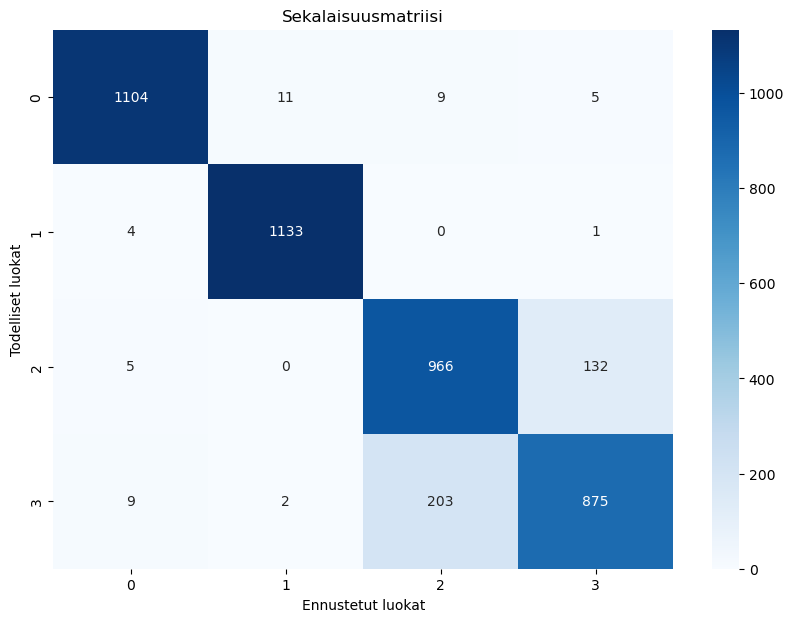

[[1104   11    9    5]
 [   4 1133    0    1]
 [   5    0  966  132]
 [   9    2  203  875]]


In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Laske sekalaista matriisia
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Visualisoi sekalaista matriisia
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(4), yticklabels=np.arange(4))
plt.xlabel('Ennustetut luokat')
plt.ylabel('Todelliset luokat')
plt.title('Sekalaisuusmatriisi')
plt.show()
print(conf_matrix)
